# Calibrating simulated frame sensor sizing for robust fit within WAC footprints

Goal: one fixed pinhole sensor model -- isotropic focal length, principal point exactly at image
center (`cu = cv = image_size / 2`) -- that reliably renders inside real WAC crop footprints across
"nominal" EDRs, plus a rejection rule for non-nominal ones before dataset generation. Per-EDR
ground truth here (a real crop's own footprint corners, and the focal length a symmetric FOV needs
to just cover them) comes from this project's existing camera-pose pipeline; this notebook only
asks what size and shape the *fixed* model should be, not how that pipeline works.

Two geometric quantities matter, and they aren't coupled the way "off-nadir angle" alone would
suggest:
- **Size** -- the focal length needed to keep a render inside a crop's along-track extent -- tracks
  altitude, not off-nadir angle.
- **Pointing direction** -- decomposed as pitch (along-track) and yaw (cross-track) degrees from
  true nadir (`camera.boresight_pitch_yaw_deg`). A real EDR's boresight sits at a consistent,
  non-zero nominal point, not at nadir itself, so the rejection rule this notebook derives is a
  disk of some radius around that point -- both axes checked together, not just how far off-nadir
  a candidate is.

In [1]:
import dataclasses

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import trntest
from trntest import camera, catalog, spice_kernels, tie_points
from trntest.config import MOON_RADIUS_KM

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()
dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
image_size = session.config.image_size

print(f"{len(dataset)} manifest rows")

81 manifest rows


## Cheap, ISIS-free geometry sweep

For every manifest row: altitude, slant range, total off-nadir angle, and its pitch/yaw
decomposition (`camera.boresight_pitch_yaw_deg`, fed the *raw* SPICE-frame boresight here) -- pure
SPICE, no ISIS, so this covers the whole manifest in seconds regardless of which entries have been
populated. `off_nadir_deg`/`pitch_deg`/`yaw_deg` here are the raw SPICE-frame quantities, not the
post-boresight-correction ones `build_camera` itself reports (WAC-VIS's real boresight sits several
degrees off the raw frame's nominal axis) -- a cheap screening signal for picking candidates worth a
closer look, not the quantity the eventual rejection rule is expressed in. See "What would keeping
each outlier cost?" below for the real, corrected values on the candidates this notebook samples.

In [2]:
rows = []
for entry in dataset:
    row = entry.row
    frame_timing = entry.frame_timing
    per_image_config = entry.per_image_config
    spice_kernels.fetch_and_furnish(frame_timing.start_time, per_image_config)

    center_frame_index = row["center_frame_index"]
    et = camera.frame_et(frame_timing, center_frame_index)
    c_m, r_cam_to_me, slant_range_km, off_nadir_deg = camera.camera_pose_moon_me(et)
    forward_step_km = camera.ground_track_step_km(frame_timing, center_frame_index)
    boresight_raw = r_cam_to_me @ np.array([0.0, 0.0, 1.0])
    pitch_deg, yaw_deg = camera.boresight_pitch_yaw_deg(c_m / 1000.0, boresight_raw, forward_step_km)

    rows.append(
        dict(
            product_id=entry.product_id,
            center_lat_deg=row["center_lat_deg"],
            altitude_km=np.linalg.norm(c_m / 1000.0) - MOON_RADIUS_KM,
            slant_range_km=slant_range_km,
            off_nadir_deg=off_nadir_deg,
            pitch_deg=pitch_deg,
            yaw_deg=yaw_deg,
            n_frames_for_square_crop=row["n_frames_for_square_crop"],
        )
    )

geometry_df = pd.DataFrame(rows)
geometry_df.describe()

,center_lat_deg,altitude_km,slant_range_km,off_nadir_deg,pitch_deg,yaw_deg,n_frames_for_square_crop
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,5.379038,108.353046,108.472747,1.531936,1.080749,0.089624,70.913580
std,50.264209,21.169597,21.106033,2.321959,0.368222,2.540345,3.695259
min,-68.235000,73.143949,73.158142,1.102563,-1.424222,-3.476246,65.000000
25%,-46.978100,85.419662,85.506619,1.106059,1.084112,-0.221438,68.000000
50%,8.336300,116.730315,116.753587,1.107860,1.085598,-0.219642,71.000000
75%,53.722000,127.620984,127.646514,1.110741,1.087678,-0.217981,72.000000
max,73.248300,130.408054,130.434157,17.416788,3.092042,17.365300,78.000000


## Where the variation actually lives

Left: footprint size (`n_frames_for_square_crop`) tracks altitude, which tracks latitude through
LRO's eccentric, near-polar orbit -- not a curvature effect (a few-degree FOV over ~100 km is far
too small for the Moon's own shape to matter), an orbital-mechanics one. Right: off-nadir tilt is
almost entirely a yaw (cross-track) effect -- `pitch_deg` sits in a narrow band across nearly every
row, while `yaw_deg` is what separates the outliers.

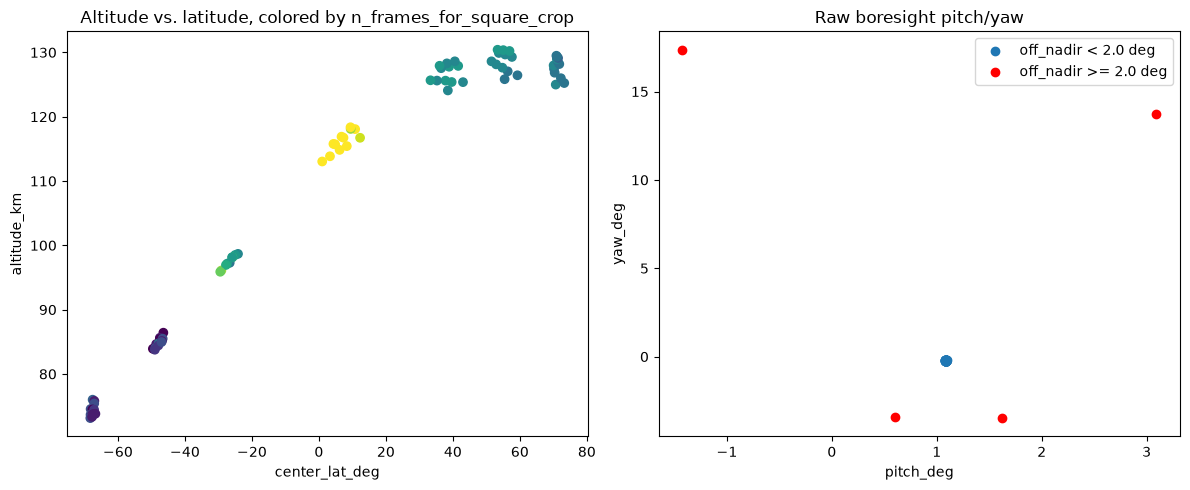

In [3]:
TIGHT_CLUSTER_DEG = 2.0  # marks the visual gap below, a screening cut -- not the final rejection rule

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(geometry_df["center_lat_deg"], geometry_df["altitude_km"], c=geometry_df["n_frames_for_square_crop"])
axes[0].set_xlabel("center_lat_deg")
axes[0].set_ylabel("altitude_km")
axes[0].set_title("Altitude vs. latitude, colored by n_frames_for_square_crop")

nominal = geometry_df["off_nadir_deg"] < TIGHT_CLUSTER_DEG
axes[1].scatter(
    geometry_df.loc[nominal, "pitch_deg"],
    geometry_df.loc[nominal, "yaw_deg"],
    label=f"off_nadir < {TIGHT_CLUSTER_DEG} deg",
)
axes[1].scatter(
    geometry_df.loc[~nominal, "pitch_deg"],
    geometry_df.loc[~nominal, "yaw_deg"],
    color="red",
    label=f"off_nadir >= {TIGHT_CLUSTER_DEG} deg",
)
axes[1].set_xlabel("pitch_deg")
axes[1].set_ylabel("yaw_deg")
axes[1].set_title("Raw boresight pitch/yaw")
axes[1].legend()
plt.tight_layout()

## The gap in the data

`off_nadir_deg` separates the manifest into a tight cluster under ~1.15 deg and 4 outliers, with
nothing in between until 3.47 deg -- and a second, much larger gap after that, up to 14.03 deg.
`off_nadir_deg < 2` sits in the first gap; it's not yet clear whether it's the *right* place to cut,
or just *a* defensible one. The two outliers just past it (3.47, 3.84 deg) might be cheap to keep.

In [4]:
outliers = geometry_df[geometry_df["off_nadir_deg"] >= TIGHT_CLUSTER_DEG].sort_values("off_nadir_deg", ascending=False)
print(f"{len(outliers)} of {len(geometry_df)} rows exceed off_nadir_deg >= {TIGHT_CLUSTER_DEG}:")
outliers[["product_id", "center_lat_deg", "off_nadir_deg", "pitch_deg", "yaw_deg"]]

4 of 81 rows exceed off_nadir_deg >= 2.0:


,product_id,center_lat_deg,off_nadir_deg,pitch_deg,yaw_deg
51,M1327265552CE,-29.1023,17.416788,-1.424222,17.365300
43,M1327258213CE,-47.8313,14.026818,3.092042,13.707650
30,M1327244120CE,-49.5604,3.835090,1.623742,-3.476246
37,M1327251520CE,-24.9840,3.467387,0.602358,-3.414917


## Sensor size across the tight cluster

`camera.build_camera`'s real, ISIS-derived `fu`, solved fresh per EDR (`fixed_sensor=False` --
`entry.camera` itself now returns the fixed model this notebook is scoping, so getting the real
per-EDR ground truth means calling `build_camera` directly) for one candidate per altitude band
identified above, all inside the tight cluster and already crop-cached from prior work, to keep this
fast. `fu` doesn't depend on the boresight's pointing direction -- it's set purely by how many
pixels are needed to span a crop's own near+far along-track extent -- so this is meaningful on its
own, before deciding anything about pointing.

In [5]:
tight_sample_ids = [
    "M1327222602CE",  # ~-67 deg lat, low-altitude band
    "M1327223032CE",  # ~-47 deg lat
    "M1327223360CE",  # ~-27 deg lat
    "M1327223847CE",  # ~8 deg lat, peak n_frames_for_square_crop
    "M1327218124CE",  # ~59 deg lat, high-altitude band
]
entries = {pid: dataset[pid] for pid in tight_sample_ids}
solved_cameras: dict[str, camera.Camera] = {}


def solved_camera(product_id: str) -> camera.Camera:
    """This EDR's own real per-EDR sensor fit -- the ground truth this notebook measures the fixed
    model against, and the only way to examine an EDR outside its nominal envelope at all, since
    `entry.camera` (`fixed_sensor=True`) asserts it's within the nominal pointing disk."""
    if product_id not in solved_cameras:
        solved_cameras[product_id] = camera.build_camera(entries[product_id].per_image_config, fixed_sensor=False)
    return solved_cameras[product_id]


def crop_footprint(product_id: str) -> dict:
    entry = entries[product_id]
    return tie_points.crop_footprint_corners_for_camera(
        entry.frame_timing, solved_camera(product_id), entry.per_image_config
    )


def corrected_pitch_yaw_deg(product_id: str) -> tuple[float, float]:
    """The *corrected* (post-boresight-correction) boresight's own pitch/yaw -- what
    `NOMINAL_BORESIGHT_PITCH_DEG`/`NOMINAL_BORESIGHT_YAW_DEG` are measured in."""
    cam = solved_camera(product_id)
    c_km = np.array(cam.camera_center_moon_me_m) / 1000.0
    boresight_me = np.array(cam.r_cam_to_me)[:, 2]  # unaffected by the k-twist -- see camera.py's build_camera
    frame_timing = entries[product_id].frame_timing
    forward_step_km = camera.ground_track_step_km(frame_timing, cam.center_frame_index)
    return camera.boresight_pitch_yaw_deg(c_km, boresight_me, forward_step_km)


tight_summary = pd.DataFrame(
    [
        dict(product_id=pid, fu=solved_camera(pid).focal_length_u_px, pitch_deg=p, yaw_deg=y)
        for pid, (p, y) in ((pid, corrected_pitch_yaw_deg(pid)) for pid in tight_sample_ids)
    ]
)
print(tight_summary)
tight_fu = tight_summary.set_index("product_id")["fu"]
recommended_f_tight = tight_fu.max()
print(f"\nrecommended_f (tight cluster only) = {recommended_f_tight:.2f}")

      product_id           fu  pitch_deg   yaw_deg
0  M1327222602CE  1282.703889   7.605905 -0.092394
1  M1327223032CE  1285.440540   7.521931 -0.087524
2  M1327223360CE  1291.667464   7.169197 -0.071079
3  M1327223847CE  1286.075191   6.963850 -0.066928
4  M1327218124CE  1269.417572   6.299088 -0.076540

recommended_f (tight cluster only) = 1291.67


`pitch_deg`/`yaw_deg` above are the *corrected* boresight's own pointing direction -- several
degrees off from the raw sweep's values for these same rows (expected: WAC-VIS's real boresight
sits several degrees off the raw SPICE frame's nominal axis). Yaw is small but *not* noise: all 5
values are consistently negative (-0.09 to -0.07 deg, std ~0.01 deg) rather than scattered around
zero -- a real, small, repeatable bias, not a rounding artifact. This is the nominal pointing
direction the disk-based rejection rule is centered on.

## Centered principal point: does it fit?

Take `fu = fv = recommended_f_tight` and `cu = cv = image_size / 2` -- the target design -- and
check each tight-cluster candidate's own real crop footprint (near/far along-track extent, via
`camera.along_track_extent_km`) against what this camera's own footprint (`camera.footprint_lonlat`)
actually reaches. A positive margin means the render lands inside the real crop on that side; negative
means it overshoots.

In [6]:
def margins_km(product_id: str, f: float, cv: float) -> tuple[float, float]:
    cam = solved_camera(product_id)
    c_km = np.array(cam.camera_center_moon_me_m) / 1000.0
    r_cam_to_me = np.array(cam.r_cam_to_me)
    along_track_axis_me = np.array(cam.camera_along_track_direction_moon_me)
    boresight_ground_km = camera.boresight_ground_point_km(c_km, r_cam_to_me)
    target_near_km, target_far_km = camera.along_track_extent_km(
        crop_footprint(product_id), boresight_ground_km, along_track_axis_me
    )
    footprint = camera.footprint_lonlat(c_km, r_cam_to_me, f, f, image_size / 2.0, cv, image_size)
    achieved_near_km, achieved_far_km = camera.along_track_extent_km(
        footprint, boresight_ground_km, along_track_axis_me
    )
    return target_near_km - achieved_near_km, target_far_km - achieved_far_km


def centered_margins_km(product_id: str, f: float) -> tuple[float, float]:
    return margins_km(product_id, f, image_size / 2.0)


tight_margins = pd.DataFrame(
    [
        dict(product_id=pid, near_margin_km=n, far_margin_km=f)
        for pid, (n, f) in ((pid, centered_margins_km(pid, recommended_f_tight)) for pid in tight_sample_ids)
    ]
)
tight_margins

,product_id,near_margin_km,far_margin_km
0,M1327222602CE,4.905853,1.228419
1,M1327223032CE,5.496784,1.234768
2,M1327223360CE,5.884314,1.313820
3,M1327223847CE,7.226973,1.966726
4,M1327218124CE,8.848723,3.240176


Every margin is comfortably positive -- a centered principal point fits the tight cluster with room
to spare. That's the working assumption for the rest of this notebook; the question from here is how
far it can be pushed before it stops holding.

## What would keeping each outlier cost?

Each outlier's own required `fu`, and its distance -- both pitch and yaw together, not off-nadir
magnitude alone -- from the nominal pointing point measured above, to see whether admitting an
outlier costs a little unused margin (fine) or lands far outside the disk (not fine).

In [7]:
NOMINAL_BORESIGHT_PITCH_DEG = tight_summary["pitch_deg"].mean()
NOMINAL_BORESIGHT_YAW_DEG = tight_summary["yaw_deg"].mean()


def disk_distance_deg(product_id: str) -> float:
    pitch_deg, yaw_deg = corrected_pitch_yaw_deg(product_id)
    return float(np.hypot(pitch_deg - NOMINAL_BORESIGHT_PITCH_DEG, yaw_deg - NOMINAL_BORESIGHT_YAW_DEG))


outlier_ids = list(outliers["product_id"])
entries.update({pid: dataset[pid] for pid in outlier_ids})
outlier_summary = pd.DataFrame(
    [
        dict(product_id=pid, fu=solved_camera(pid).focal_length_u_px, disk_distance_deg=disk_distance_deg(pid))
        for pid in outlier_ids
    ]
)
print(f"Outlier fu vs. tight cluster range ({tight_fu.min():.1f} - {tight_fu.max():.1f}):")
print(outlier_summary)

moderate_ids = ["M1327244120CE", "M1327251520CE"]
extreme_ids = ["M1327258213CE", "M1327265552CE"]

recommended_f = pd.concat([tight_fu, outlier_summary.set_index("product_id")["fu"].loc[moderate_ids]]).max()
print(f"\nrecommended_f (tight cluster + moderate outliers) = {recommended_f:.2f}")

Outlier fu vs. tight cluster range (1269.4 - 1291.7):
      product_id           fu  disk_distance_deg
0  M1327265552CE  1209.316999          18.398811
1  M1327258213CE  1209.316999          14.564136
2  M1327244120CE  1342.522354           2.605725
3  M1327251520CE  1321.372214           4.273143

recommended_f (tight cluster + moderate outliers) = 1342.52


In [8]:
cost_rows = []
for pid in tight_sample_ids + moderate_ids + extreme_ids:
    near_km, far_km = centered_margins_km(pid, recommended_f)
    cost_rows.append(
        dict(
            product_id=pid,
            group="tight" if pid in tight_sample_ids else ("moderate" if pid in moderate_ids else "extreme"),
            disk_distance_deg=disk_distance_deg(pid),
            near_margin_km=near_km,
            far_margin_km=far_km,
        )
    )
cost_df = pd.DataFrame(cost_rows)
cost_df

,product_id,group,disk_distance_deg,near_margin_km,far_margin_km
0,M1327222602CE,tight,0.494095,6.235078,3.003871
1,M1327223032CE,tight,0.410027,7.004867,3.248622
2,M1327223360CE,tight,0.057734,7.613973,3.599758
3,M1327223847CE,tight,0.148626,9.298695,4.697082
4,M1327218124CE,tight,0.812909,11.151926,6.204222
5,M1327244120CE,moderate,2.605725,6.568506,2.726996
6,M1327251520CE,moderate,4.273143,8.461039,4.041973
7,M1327258213CE,extreme,14.564136,5.023077,-2.176969
8,M1327265552CE,extreme,18.398811,7.051982,2.255898


The two moderate outliers need `fu` up to ~1345 -- about 4% above the tight cluster's own max
(~1292) -- and at that shared, larger `f` their own centered margins come out comparable to the
tight cluster's own range (one far margin lands just under it, ~2.7 km vs. a ~3.0 km floor -- not a
meaningful difference). Their pitch/yaw distance from nominal (2.6, 4.3 deg) stays inside a 5 deg
disk. Cheap to keep.

The two extreme outliers are a different story: 14.6 and 18.4 deg from nominal, an order of
magnitude past the moderate outliers and nowhere near a 5 deg disk. At the shared `f` above, one
(`M1327258213CE`) also comes out **negative** on its far margin -- an actual coverage failure, not
just reduced margin. Neither fits the centered-principal-point premise the way the rest of the
manifest does -- this is the yaw-driven asymmetry breaking down once cross-track tilt (which a
centered `cu` never corrects for) gets large enough to distort the along-track corners too, not a
small stretch of an otherwise-fine fit.

**`NOMINAL_POINTING_DISK_RADIUS_DEG = 5.0`**: keeps the two moderate outliers (2.6, 4.3 deg from
nominal), excludes the two extreme ones (14.6, 18.4 deg) with a wide margin either side of the cut.

In [9]:
NOMINAL_POINTING_DISK_RADIUS_DEG = 5.0
sample_product_ids = tight_sample_ids + moderate_ids
print(f"NOMINAL_BORESIGHT_PITCH_DEG = {NOMINAL_BORESIGHT_PITCH_DEG:.4f}")
print(f"NOMINAL_BORESIGHT_YAW_DEG = {NOMINAL_BORESIGHT_YAW_DEG}")
print(f"NOMINAL_POINTING_DISK_RADIUS_DEG = {NOMINAL_POINTING_DISK_RADIUS_DEG}")
print(f"fu = fv = {recommended_f:.2f}")
print(f"cu = cv = {image_size / 2.0:.2f}")

NOMINAL_BORESIGHT_PITCH_DEG = 7.1120
NOMINAL_BORESIGHT_YAW_DEG = -0.07889286502747542
NOMINAL_POINTING_DISK_RADIUS_DEG = 5.0
fu = fv = 1342.52
cu = cv = 658.00


## Does the nominal pointing direction hold in the opposite yaw-flip state?

LRO's WAC is body-fixed and periodically does a 180-degree yaw flip (~every 6 months) --
`camera.boresight_rotation_k` already tracks which state a pose is in. If the nominal pointing
direction above is a real, physical fact (not an artifact of this one manifest's short time window),
a manifest from the opposite state should show it mirrored on both axes: the whole spacecraft
rotates together, so both the raw attitude bias and the hardware boresight correction should flip
sign together.

Checked directly: a real catalog query ~6 months after this manifest's own window (chosen only for
the yaw-flip cadence, not cherry-picked for geometry), a cheap raw-pose sweep across latitude, and
one real ISIS-corrected sample.

In [10]:
opposite_window_start = pd.Timestamp("2020-05-01", tz="UTC")
opposite_candidates = catalog.list_products(
    session.config, catalog.EDR_PRODUCT_TYPE, opposite_window_start, opposite_window_start + pd.Timedelta(days=1)
)
opposite_candidates = opposite_candidates.sort_values("center_lat_deg").reset_index(drop=True)
opposite_picks = opposite_candidates.iloc[
    [0, len(opposite_candidates) // 4, len(opposite_candidates) // 2, 3 * len(opposite_candidates) // 4, -1]
]

opposite_rows = []
for _, row in opposite_picks.iterrows():
    per_image_config = dataclasses.replace(
        session.config,
        edr_volume=row["volume"],
        edr_subdir=row["subdir"],
        edr_doy=str(row["doy"]),
        edr_product=row["product_id"],
    )
    frame_timing = camera.fetch_frame_timing(per_image_config)
    spice_kernels.fetch_and_furnish(frame_timing.start_time, per_image_config)
    center_frame_index = frame_timing.nframes / 2.0
    et = camera.frame_et(frame_timing, center_frame_index)
    c_m, r_cam_to_me, _, off_nadir_deg = camera.camera_pose_moon_me(et)
    forward_step_km = camera.ground_track_step_km(frame_timing, center_frame_index)
    k = camera.boresight_rotation_k(r_cam_to_me, forward_step_km)
    boresight_raw = r_cam_to_me @ np.array([0.0, 0.0, 1.0])
    pitch_deg, yaw_deg = camera.boresight_pitch_yaw_deg(c_m / 1000.0, boresight_raw, forward_step_km)
    opposite_rows.append(
        dict(
            product_id=row["product_id"],
            volume=row["volume"],
            subdir=row["subdir"],
            doy=row["doy"],
            center_lat_deg=row["center_lat_deg"],
            off_nadir_deg=off_nadir_deg,
            k=k,
            pitch_deg=pitch_deg,
            yaw_deg=yaw_deg,
        )
    )

opposite_df = pd.DataFrame(opposite_rows)
print(f"Original manifest's own k (all 9 samples above): {solved_camera(tight_sample_ids[0]).boresight_rotation_k}")
opposite_df[["product_id", "center_lat_deg", "off_nadir_deg", "k", "pitch_deg", "yaw_deg"]]

Original manifest's own k (all 9 samples above): 3


,product_id,center_lat_deg,off_nadir_deg,k,pitch_deg,yaw_deg
0,M1342934651CE,-85.2421,1.110761,1,-1.088257,0.222508
1,M1342933872CE,-45.3475,4.745952,1,-0.601943,4.707969
2,M1342967691CE,6.4850,1.082162,1,-1.059906,0.218392
3,M1342981144CE,53.0137,1.114190,1,-1.091019,0.226102
4,M1342931132CE,85.2422,1.112111,1,-1.089356,0.223872


`k` is the opposite of the original manifest's for every candidate here, and raw `pitch_deg`/
`yaw_deg` mirror the original tight cluster's own raw values on both axes -- confirms the yaw-flip
signature. Now the real, ISIS-corrected check: the most nominal-looking candidate from this set (by
`off_nadir_deg`), through the full `build_camera(fixed_sensor=False)` re-aim.

In [11]:
opposite_pick = opposite_df.loc[opposite_df["off_nadir_deg"].idxmin()]
opposite_per_image_config = dataclasses.replace(
    session.config,
    edr_volume=opposite_pick["volume"],
    edr_subdir=opposite_pick["subdir"],
    edr_doy=str(opposite_pick["doy"]),
    edr_product=opposite_pick["product_id"],
    target_frame_index=0,
    output_dir=session.config.output_dir / "opposite_yaw_check" / opposite_pick["product_id"],
)
opposite_frame_timing = camera.fetch_frame_timing(opposite_per_image_config)
opposite_per_image_config = dataclasses.replace(
    opposite_per_image_config, target_frame_index=round(opposite_frame_timing.nframes / 2.0 - 35)
)
opposite_cam = camera.build_camera(opposite_per_image_config, fixed_sensor=False)
opposite_c_km = np.array(opposite_cam.camera_center_moon_me_m) / 1000.0
opposite_boresight_me = np.array(opposite_cam.r_cam_to_me)[:, 2]
opposite_forward_step_km = camera.ground_track_step_km(opposite_frame_timing, opposite_cam.center_frame_index)
opposite_pitch_deg, opposite_yaw_deg = camera.boresight_pitch_yaw_deg(
    opposite_c_km, opposite_boresight_me, opposite_forward_step_km
)
mirrored_pitch_deg, mirrored_yaw_deg = -NOMINAL_BORESIGHT_PITCH_DEG, -NOMINAL_BORESIGHT_YAW_DEG

print(f"{opposite_pick['product_id']}: k={opposite_cam.boresight_rotation_k}")
print(f"  corrected pitch={opposite_pitch_deg:.2f}, yaw={opposite_yaw_deg:.2f} deg")
print(f"  mirrored nominal: pitch={mirrored_pitch_deg:.2f}, yaw={mirrored_yaw_deg:.2f} deg")
print(
    f"  distance from mirrored nominal: "
    f"{np.hypot(opposite_pitch_deg - mirrored_pitch_deg, opposite_yaw_deg - mirrored_yaw_deg):.2f} deg"
)

M1342967691CE: k=1
  corrected pitch=-7.47, yaw=0.11 deg
  mirrored nominal: pitch=-7.11, yaw=0.08 deg
  distance from mirrored nominal: 0.36 deg


This one candidate lands close to the mirrored nominal point -- consistent with the "the whole
spacecraft rotates together" model, on a single real sample from the opposite state (not a full
recalibration of it). `camera.nominal_boresight_pitch_yaw_deg` implements exactly this: unmirrored
for `k == _REVERSED_TIME_K` (the state this manifest's own samples are in), negated on both axes for
`k == _FORWARD_TIME_K`.

## Side experiment: does letting `cv` float buy anything?

`camera.solve_corrected_fov` (the `fixed_sensor=False` per-EDR machinery) doesn't center `cv` -- it
shifts it to balance near/far margins exactly, using up whatever slack a shared `f` leaves. Given
the centered margins above are already comfortably positive for every kept candidate, is a fitted
`cv` worth the extra per-EDR complexity? Compare both variants directly, across the final
7-candidate sample.

In [12]:
fit_cv = (
    image_size / 2.0
    + pd.Series({pid: solved_camera(pid).principal_point_v_px - image_size / 2.0 for pid in sample_product_ids}).mean()
)

side_rows = []
for pid in sample_product_ids:
    for label, cv in [("fit", fit_cv), ("centered", image_size / 2.0)]:
        near_km, far_km = margins_km(pid, recommended_f, cv)
        side_rows.append(dict(product_id=pid, cv_variant=label, near_margin_km=near_km, far_margin_km=far_km))

side_df = pd.DataFrame(side_rows)
side_df.pivot(index="product_id", columns="cv_variant", values=["near_margin_km", "far_margin_km"])

near_margin_km           far_margin_km          
cv_variant          centered       fit      centered       fit
product_id                                                    
M1327218124CE      11.151926  8.444828      6.204222  9.649935
M1327222602CE       6.235078  4.661356      3.003871  5.085573
M1327223032CE       7.004867  5.221868      3.248622  5.605418
M1327223360CE       7.613973  5.572398      3.599758  6.269851
M1327223847CE       9.298695  6.859734      4.697082  7.875350
M1327244120CE       6.568506  4.796037      2.726996  5.007059
M1327251520CE       8.461039  6.362582      4.041973  6.710717

Fitting `cv` shifts slack from the far side to the near side -- expected, since moving `cv` away
from the near edge gives it more room and takes room from the far edge -- but every margin stays
positive either way, on this sample. Fitting buys back a bit of otherwise-unused margin, not
coverage. Not worth the per-EDR complexity for a sensor model that's supposed to be simple and fixed.

## Recommendation

**Rejection rule**: exclude any EDR whose `build_camera`-reported (post-correction) boresight
pointing direction lands more than `NOMINAL_POINTING_DISK_RADIUS_DEG` from
`nominal_boresight_pitch_yaw_deg(k)` before generating a `hillshade`/`reproject` pair from it.

**Fixed sensor parameters** (at `image_size` pixels, isotropic, centered principal point):

In [13]:
print(f"NOMINAL_BORESIGHT_PITCH_DEG = {NOMINAL_BORESIGHT_PITCH_DEG:.6f}")
print(f"NOMINAL_BORESIGHT_YAW_DEG = {NOMINAL_BORESIGHT_YAW_DEG}")
print(f"NOMINAL_POINTING_DISK_RADIUS_DEG = {NOMINAL_POINTING_DISK_RADIUS_DEG}")
print(f"image_size = {image_size}")
print(f"FIXED_FOCAL_LENGTH_PX = {recommended_f:.6f}")
print(f"cu = cv = {image_size / 2.0:.2f}")

NOMINAL_BORESIGHT_PITCH_DEG = 7.111994
NOMINAL_BORESIGHT_YAW_DEG = -0.07889286502747542
NOMINAL_POINTING_DISK_RADIUS_DEG = 5.0
image_size = 1316
FIXED_FOCAL_LENGTH_PX = 1342.522354
cu = cv = 658.00
